In [1]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
from torchvision import datasets,transforms
import timm
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RND = 42
random.seed(RND); np.random.seed(RND); torch.manual_seed(RND)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

In [2]:
import kagglehub

path = kagglehub.dataset_download("sheikhzaib/sports-image-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sheikhzaib/sports-image-image-classification


In [3]:
data_dir = "/kaggle/input/datasets/sheikhzaib/sports-image-image-classification/sports"
dataset = datasets.ImageFolder(root=data_dir)

print(len(dataset))

14160


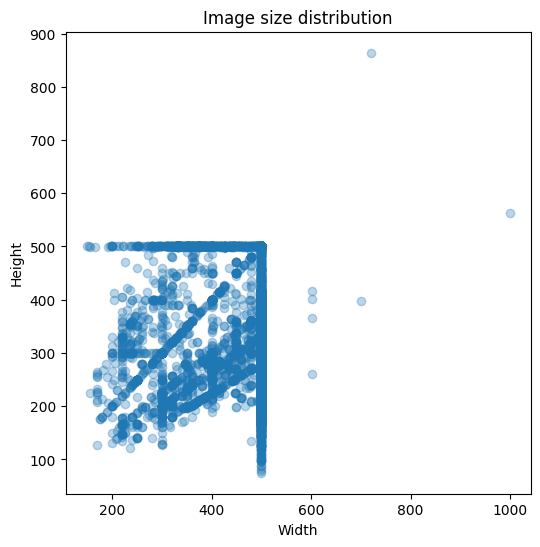

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

widths = []
heights = []

# dataset.samples = list (path, label)
for path, _ in dataset.samples:
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        continue

# 🎯 scatter plot
plt.figure(figsize=(6,6))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image size distribution")
plt.show()

In [5]:
targets = np.array(dataset.targets)

train_idx, temp_idx = train_test_split(
    np.arange(len(dataset)),
    test_size=0.3,
    stratify=dataset.targets,
    random_state=RND
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=np.array(dataset.targets)[temp_idx],
    random_state=RND
)

train_set = Subset(dataset, train_idx)
val_set   = Subset(dataset, val_idx)
test_set  = Subset(dataset, test_idx)

train_labels = targets[train_idx]

In [6]:
def get_labels(dataset):
    if hasattr(dataset, "targets"):
        return np.array(dataset.targets)

    elif hasattr(dataset, "dataset"):  # Subset
        return np.array(dataset.dataset.targets)[dataset.indices]

    else:
        raise ValueError("Dataset type not supported")

In [7]:
def show_label_distribution(dataset, class_names=None, title='Label distribution'):
    labels = get_labels(dataset)
    # labels = dataset.targets

    counter = Counter(labels)
    sorted_items = sorted(counter.items(), key=lambda x: x[1], reverse=True)

    xs = [class_names[i] if class_names else str(i) for i, _ in sorted_items]
    ys = [count for _, count in sorted_items]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=xs, y=ys)
    plt.title(title)
    plt.xticks(rotation=45, fontsize=8, ha='right')
    plt.tight_layout(pad=2)
    plt.show()

def show_sample_grid(dataset, n=16, resize=None, class_names=None, seed=42):
    rows = int(math.sqrt(n))
    cols = rows

    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    axes = axes.flatten()

    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=n, replace=False)

    for ax, i in zip(axes, idxs):
        img, label = dataset[i]

        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)

        if resize:
            img = img.resize((resize, resize))

        ax.imshow(img)
        title = class_names[label] if class_names else str(label)
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def eda_report(train_set, val_set, test_set, class_names=None):
    print("📊 SAMPLE TRAIN")
    show_sample_grid(train_set, n=16, class_names=class_names)

    print("\n--- TRAIN ---")
    show_label_distribution(train_set, class_names, "Train")

    print("\n--- VAL ---")
    show_label_distribution(val_set, class_names, "Validation")

    print("\n--- TEST ---")
    show_label_distribution(test_set, class_names, "Test")

📊 SAMPLE TRAIN


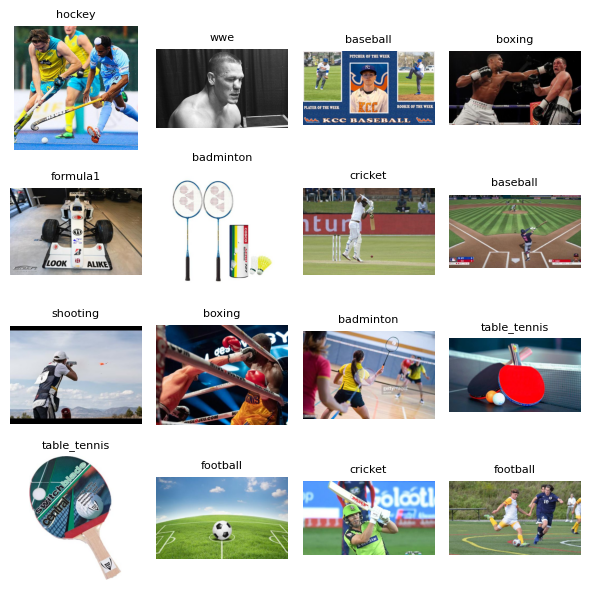


--- TRAIN ---


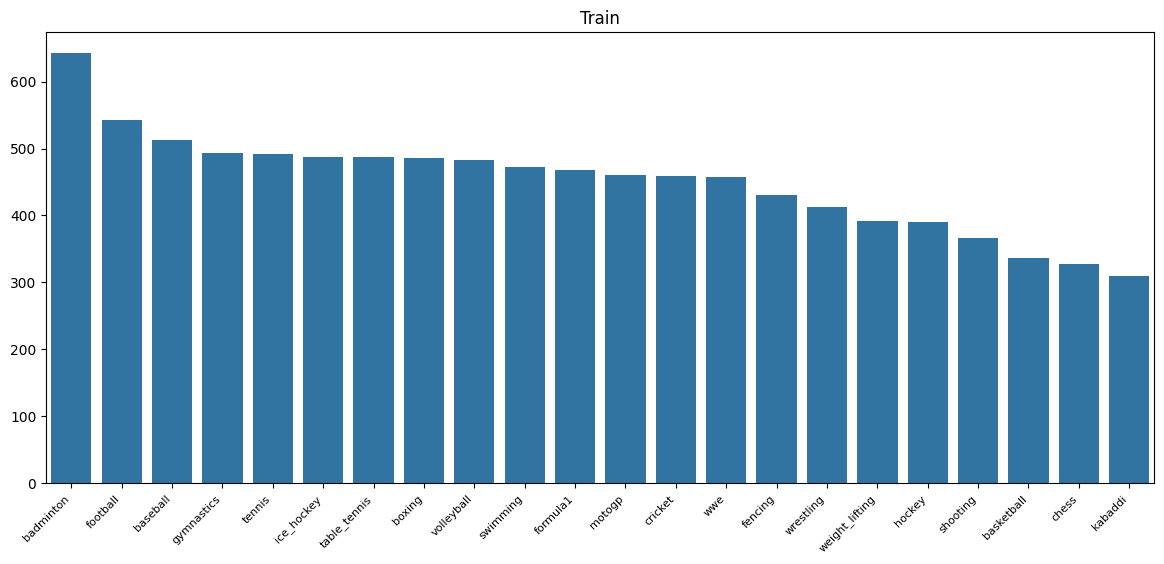


--- VAL ---


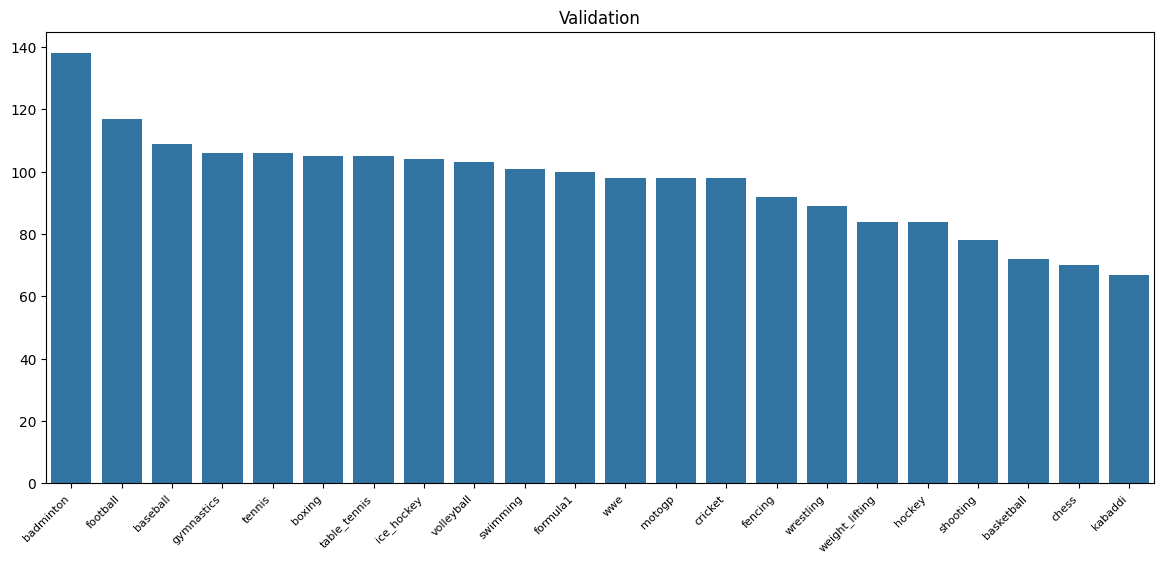


--- TEST ---


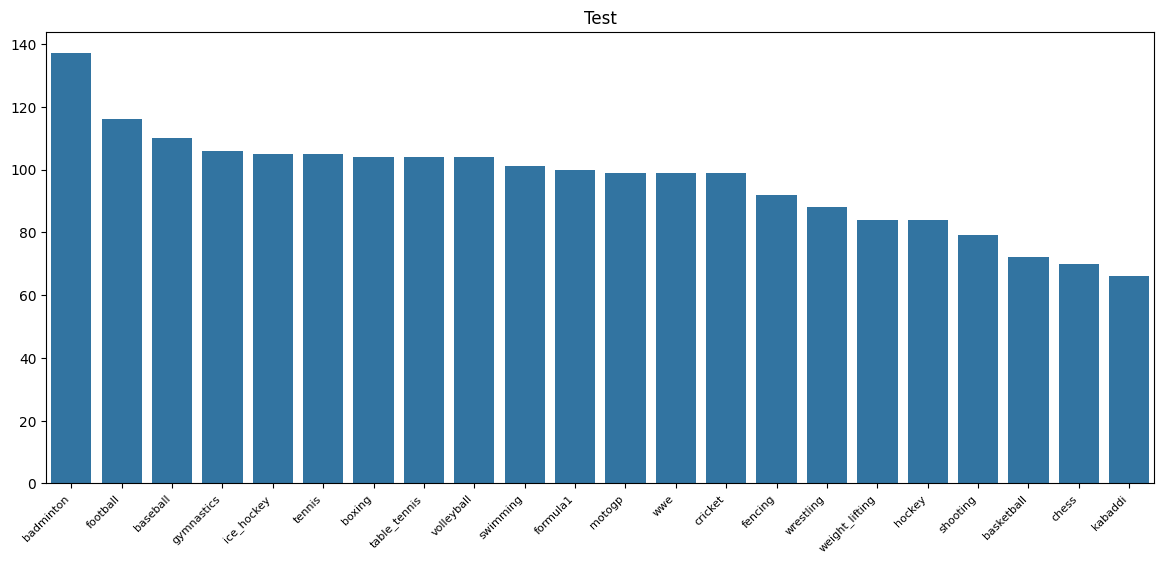

In [8]:
class_names = dataset.classes

eda_report(train_set, val_set, test_set, class_names)

In [9]:
def build_transforms(img_size=224):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.5,1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    return train_transform, val_transform

In [10]:
from torch.utils.data import WeightedRandomSampler

def build_dataloaders(train_set, val_set, test_set, config):

    batch_size = config.get("batch_size", 64)
    num_workers = config.get("num_workers", 4)

    class_counts = np.bincount(train_labels)
    class_weights = 1. / class_counts
    
    sample_weights = class_weights[train_labels]    # trọng số cho mỗi sample
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=True,
        sampler=sampler
    )

    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True,
    )

    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True,
    )

    return train_loader, val_loader, test_loader

In [11]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for images, labels in loader:  # test_loader là DataLoader của test_set
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
    
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    
    # Chuyển sang numpy
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_preds, all_labels

In [12]:
CONFIG = {
    'num_workers': 4,
    'size': 224,
    'model': 'swin_small_patch4_window7_224',
    'pretrained': True,
    'num_classes': 27,
    'batch_size': 64,
    'epochs': 3,
    'lr': 1e-5
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

train_transform, val_transform = build_transforms(CONFIG['size'])

train_set.dataset.transform = train_transform
val_set.dataset.transform   = val_transform
test_set.dataset.transform  = val_transform


train_loader, val_loader, test_loader = build_dataloaders(
    train_set, val_set, test_set, CONFIG
)


model = timm.create_model(
    CONFIG['model'],
    pretrained=CONFIG['pretrained'],
    num_classes=CONFIG['num_classes'],
    drop_rate=0.1
)

model = model.to(device)   # 🔥 QUAN TRỌNG
#model.load_state_dict(torch.load("/kaggle/input/datasets/dngtrnvnh/resnet34-sport/best_model.pth"))


# optimizer = torch.optim.SGD(
#     model.parameters(),
#     lr=CONFIG['lr'],
#     momentum=0.9,
#     weight_decay=1e-4
# )

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=0.05
)

criterion = nn.CrossEntropyLoss()

# from torch.optim.lr_scheduler import CosineAnnealingLR

# scheduler = CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-3)
# from timm.scheduler import CosineLRScheduler

# scheduler = CosineLRScheduler(
#     optimizer,
#     t_initial=5,
#     lr_min=1e-5,
#     warmup_t=2,
#     warmup_lr_init=1e-5
# )

Device: cuda


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

In [13]:
best_f1 = 0

for epoch in range(CONFIG['epochs']):
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    print(f"Epoch {epoch}:")

    for idx, (images, labels) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

        if idx % 40 == 0: print(f'Train [{idx}][{len(train_loader)}]\t| Total Loss: {total_loss / total_samples}')

    train_loss = total_loss / total_samples
    train_acc = total_correct / total_samples

    all_preds, all_labels = evaluate(model, val_loader, device)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"  Train Acc: {train_acc:.4f}")
    print(f"  Val   Acc: {val_acc:.4f}")
    print(f"  Val   F1 : {val_f1:.4f}")

    # save best
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pth")

    # scheduler.step(epoch)

Epoch 0:
Train [0][155]	| Total Loss: 3.3641204833984375
Train [40][155]	| Total Loss: 3.1779870114675384
Train [80][155]	| Total Loss: 2.9304972489674888
Train [120][155]	| Total Loss: 2.5633987444491426
  Train Acc: 0.4997
  Val   Acc: 0.8823
  Val   F1 : 0.8813
Epoch 1:
Train [0][155]	| Total Loss: 0.8012160062789917
Train [40][155]	| Total Loss: 0.6903997514306045
Train [80][155]	| Total Loss: 0.5902761412255558
Train [120][155]	| Total Loss: 0.5173078593143747
  Train Acc: 0.9156
  Val   Acc: 0.9454
  Val   F1 : 0.9455
Epoch 2:
Train [0][155]	| Total Loss: 0.3425266444683075
Train [40][155]	| Total Loss: 0.2682218206364934
Train [80][155]	| Total Loss: 0.26352291949737217
Train [120][155]	| Total Loss: 0.24793990492081838
  Train Acc: 0.9530
  Val   Acc: 0.9529
  Val   F1 : 0.9532


In [14]:
model.load_state_dict(torch.load("best_model.pth"))

all_preds, all_labels = evaluate(model, test_loader, device)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Test Acc: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-Score: {f1:.4f}")

Test Acc: 0.9539
Test Precision: 0.9547
Test Recall: 0.9539
Test F1-Score: 0.9540


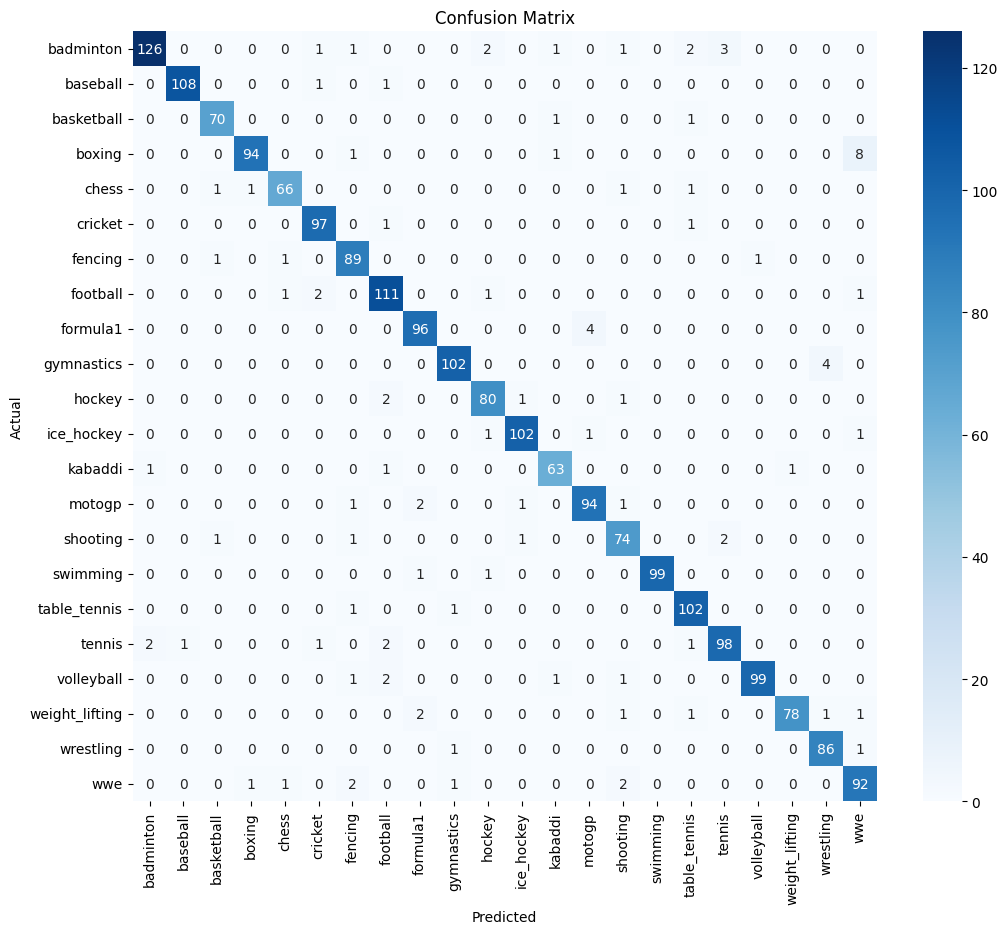

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

class_names = dataset.classes
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.forward_hook = self.target_layer.register_forward_hook(self.save_features)
        self.backward_hook = self.target_layer.register_backward_hook(self.save_gradients)

    def save_features(self, module, input, output):
        self.features = output.detach()

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        output = self.model(x)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.features).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def show_cam_on_image(img, mask, alpha=0.5):
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)

    heatmap = plt.cm.jet(mask)[:, :, :3]
    cam_img = heatmap * alpha + img_norm * (1 - alpha)
    cam_img = cam_img / cam_img.max()

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_norm)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cam_img)
    plt.title('Grad-CAM')
    plt.axis('off')

    plt.show()

#target_layer = model.layer4[-1].conv2
# target_layer = None
# for layer in reversed(model.features):
#     if isinstance(layer, torch.nn.Conv2d):
#         target_layer = layer
#         break
# grad_cam = GradCAM(model, target_layer)

# images, labels = next(iter(test_loader))
# images = images.to(device)

# idx = 1
# x = images[idx].unsqueeze(0)
# mask = grad_cam(x)

# img_np = images[idx].cpu().permute(1, 2, 0).detach().numpy() 

# show_cam_on_image(img_np, mask)

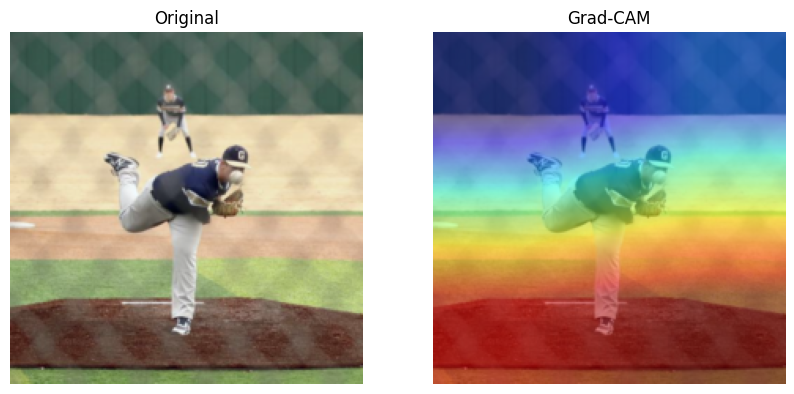

In [17]:
import torch
import torch.nn.functional as F

class ViTGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.features = None

        self.target_layer.register_forward_hook(self.save_features)
        self.target_layer.register_full_backward_hook(self.save_gradients)  # ⚠️ dùng cái này

    def save_features(self, module, input, output):
        self.features = output.detach()  # (B, N, C)

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()  # (B, N, C)

    def __call__(self, x, class_idx=None):
        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()

        grads = self.gradients   # (B, N, C)
        feats = self.features    # (B, N, C)

        # ❗ bỏ CLS token
        grads = grads[:, 1:, :]
        feats = feats[:, 1:, :]

        # reshape về spatial
        num_patches = grads.shape[1]
        size = int(num_patches ** 0.5)

        grads = grads.reshape(1, size, size, -1)
        feats = feats.reshape(1, size, size, -1)

        # Grad-CAM
        weights = grads.mean(dim=(1, 2), keepdim=True)   # (1,1,1,C)
        cam = (weights * feats).sum(dim=-1)              # (1,H,W)

        cam = F.relu(cam)

        # ✅ FIX Ở ĐÂY
        cam = cam.unsqueeze(1)   # (1,1,H,W) đúng chuẩn

        cam = F.interpolate(
            cam,
            size=x.shape[2:],   # (224,224)
            mode='bilinear',
            align_corners=False
        )

        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam

target_layer = model.layers[-1].blocks[-1]

grad_cam = ViTGradCAM(model, target_layer)

images, labels = next(iter(test_loader))
images = images.to(device)

idx = 1
x = images[idx].unsqueeze(0)

mask = grad_cam(x)

img_np = images[idx].cpu().permute(1, 2, 0).numpy()

show_cam_on_image(img_np, mask)